# AquaGuard — Water Potability Prediction
**Project Owner / Maintainer: Mashook**

Customized and extended implementation of a water-potability machine-learning workflow.

## Project Goal
Predict whether a water sample is **Potable (1)** or **Non-potable (0)** using nine physicochemical features.

### Main improvements in this version
- Leakage-safe preprocessing using a training-only pipeline.
- Median imputation, standardization and SMOTE inside the model pipeline.
- Multiple-model comparison with stratified cross-validation.
- Validation-based probability threshold selection.
- Accuracy, precision, recall, F1 and ROC-AUC.
- Feature-importance explainability.
- Reusable prediction function and ML risk indicator.

**Important:** the risk indicator is an ML confidence indicator, not a laboratory or regulatory safety certification.

## 1. Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
RANDOM_STATE=42

## 2. Load and inspect dataset

In [2]:
df=pd.read_csv("water_potability.csv")
print("Original shape:", df.shape)
df=df.drop_duplicates().reset_index(drop=True)
print("After duplicate removal:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nTarget distribution:")
print(df["Potability"].value_counts().sort_index())
display(df.head())

Original shape: (3276, 10)
After duplicate removal: (3276, 10)

Missing values:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

Target distribution:
Potability
0    1998
1    1278
Name: count, dtype: int64


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


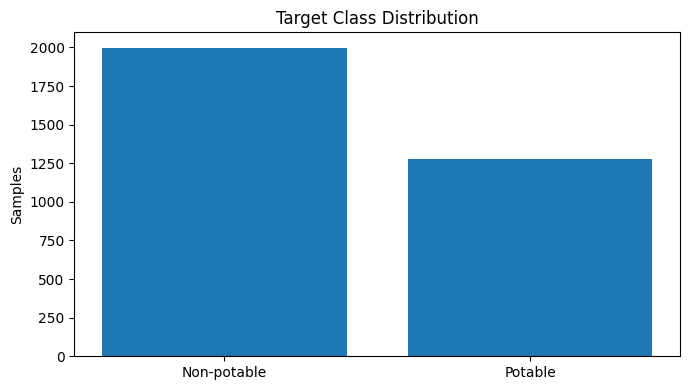

In [3]:
counts=df["Potability"].value_counts().sort_index()
plt.figure(figsize=(7,4))
plt.bar(["Non-potable","Potable"], [counts.get(0,0),counts.get(1,0)])
plt.ylabel("Samples"); plt.title("Target Class Distribution"); plt.tight_layout(); plt.show()

## 3. Exploratory analysis

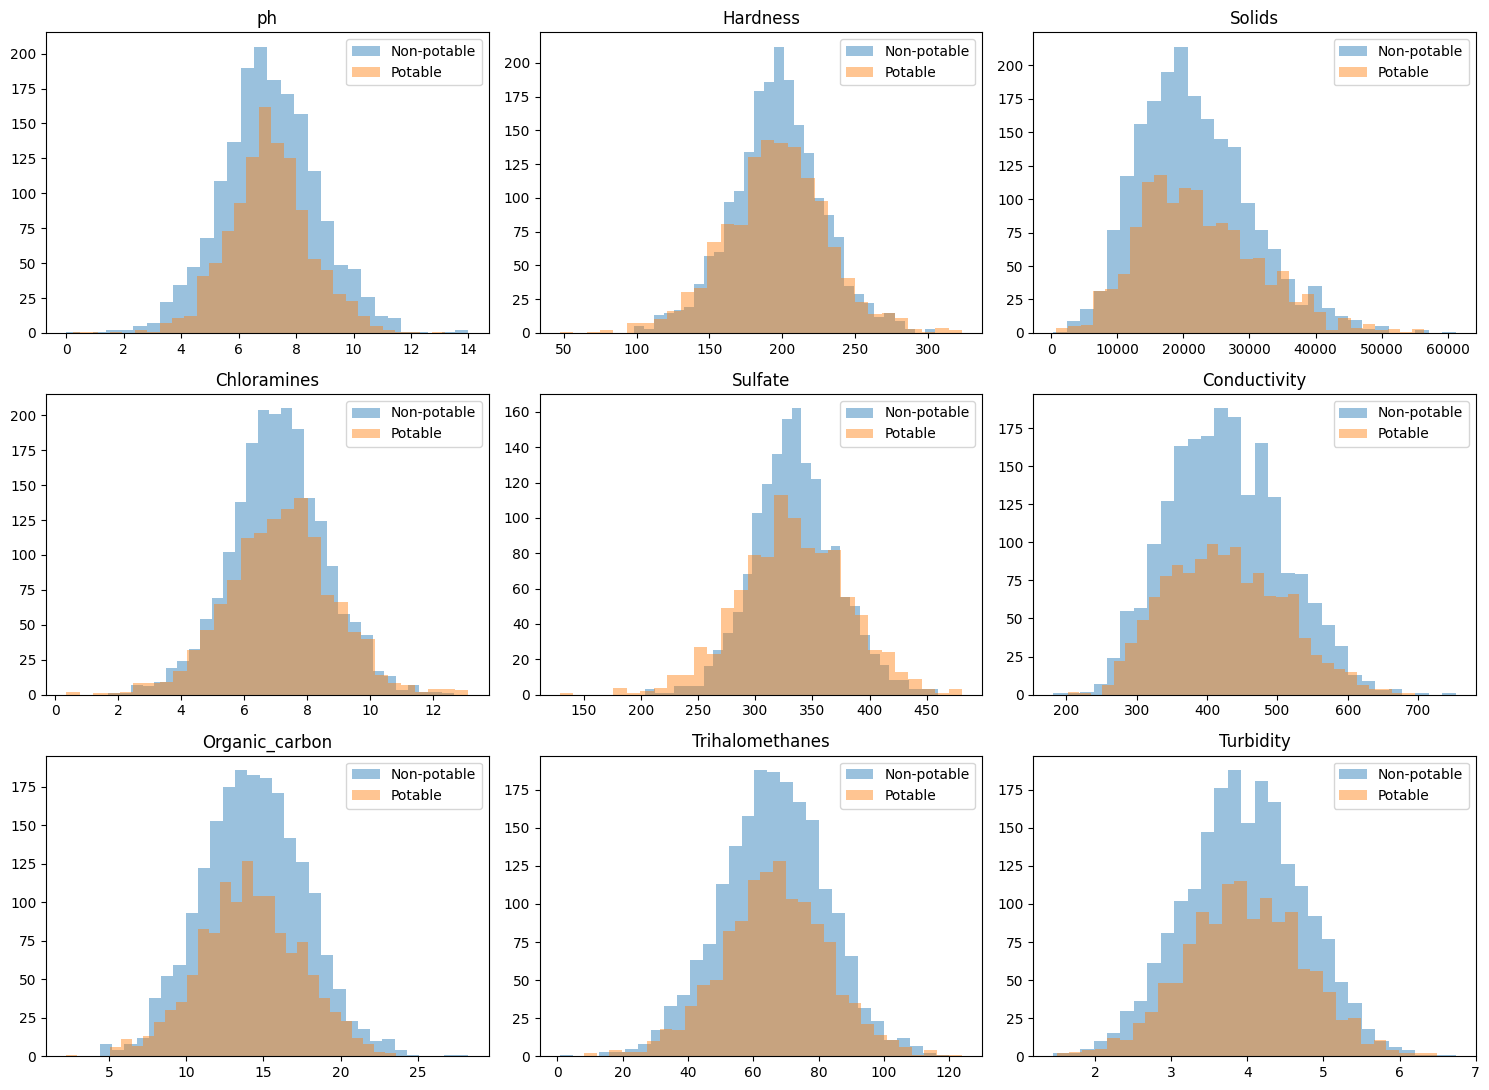

In [4]:
features=[c for c in df.columns if c!="Potability"]
fig,axes=plt.subplots(3,3,figsize=(15,11)); axes=axes.ravel()
for i,col in enumerate(features):
    for label in [0,1]:
        vals=df.loc[df["Potability"]==label,col].dropna()
        axes[i].hist(vals,bins=30,alpha=.45,label="Non-potable" if label==0 else "Potable")
    axes[i].set_title(col); axes[i].legend()
plt.tight_layout(); plt.show()

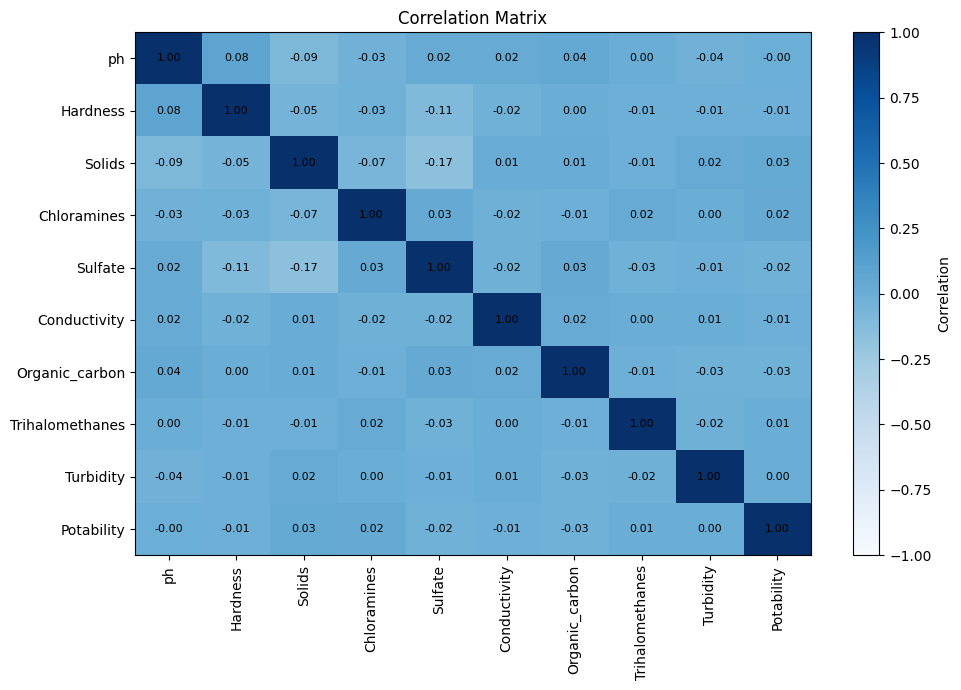

In [5]:
corr=df.corr(numeric_only=True)
plt.figure(figsize=(10,7)); plt.imshow(corr,cmap="Blues",vmin=-1,vmax=1,aspect="auto"); plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)),corr.columns,rotation=90); plt.yticks(range(len(corr.index)),corr.index)
for i in range(len(corr)):
    for j in range(len(corr.columns)): plt.text(j,i,f"{corr.iloc[i,j]:.2f}",ha="center",va="center",fontsize=8)
plt.title("Correlation Matrix"); plt.tight_layout(); plt.show()

## 4. Leakage-safe train/validation/test split
70% training, 10% validation and 20% final test. The test set remains untouched until the final evaluation.

In [6]:
X=df.drop(columns="Potability")
y=df["Potability"].astype(int)
X_train,X_temp,y_train,y_temp=train_test_split(X,y,test_size=.30,stratify=y,random_state=RANDOM_STATE)
X_val,X_test,y_val,y_test=train_test_split(X_temp,y_temp,test_size=2/3,stratify=y_temp,random_state=RANDOM_STATE)
print(X_train.shape,X_val.shape,X_test.shape)

(2293, 9) (327, 9) (656, 9)


## 5. Preprocessing pipeline

In [7]:
feature_names=list(X.columns)
preprocessor=ColumnTransformer([("numeric",Pipeline([
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler())
]),feature_names)])
def make_pipeline(model):
    return ImbPipeline([
        ("preprocessor",preprocessor),
        ("smote",SMOTE(random_state=RANDOM_STATE)),
        ("model",model)
    ])

## 6. Model comparison

In [8]:
models={
"Logistic Regression":LogisticRegression(max_iter=1500,random_state=RANDOM_STATE),
"SVM":SVC(probability=True,random_state=RANDOM_STATE),
"Random Forest":RandomForestClassifier(n_estimators=120,max_depth=16,min_samples_leaf=2,class_weight="balanced",random_state=RANDOM_STATE,n_jobs=1),
"XGBoost":XGBClassifier(n_estimators=150,max_depth=4,learning_rate=.05,subsample=.85,colsample_bytree=.85,reg_lambda=2,reg_alpha=.1,eval_metric="logloss",random_state=RANDOM_STATE,n_jobs=1)
}
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)
scoring={"accuracy":"accuracy","precision":"precision","recall":"recall","f1":"f1","roc_auc":"roc_auc"}
rows=[]; fitted={}
for name,model in models.items():
    pipe=make_pipeline(model)
    r=cross_validate(pipe,X_train,y_train,cv=cv,scoring=scoring,n_jobs=1)
    pipe.fit(X_train,y_train); fitted[name]=pipe
    rows.append({"Model":name,"CV Accuracy":r["test_accuracy"].mean(),"CV Precision":r["test_precision"].mean(),"CV Recall":r["test_recall"].mean(),"CV F1":r["test_f1"].mean(),"CV ROC-AUC":r["test_roc_auc"].mean()})
comparison=pd.DataFrame(rows).sort_values("CV F1",ascending=False).reset_index(drop=True)
display(comparison.round(4))

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
0,SVM,0.6502,0.5455,0.6279,0.5828,0.6971
1,Random Forest,0.6611,0.5724,0.5363,0.5523,0.6901
2,XGBoost,0.6337,0.5310,0.5609,0.5444,0.6748
3,Logistic Regression,0.4880,0.3775,0.4760,0.4207,0.4912


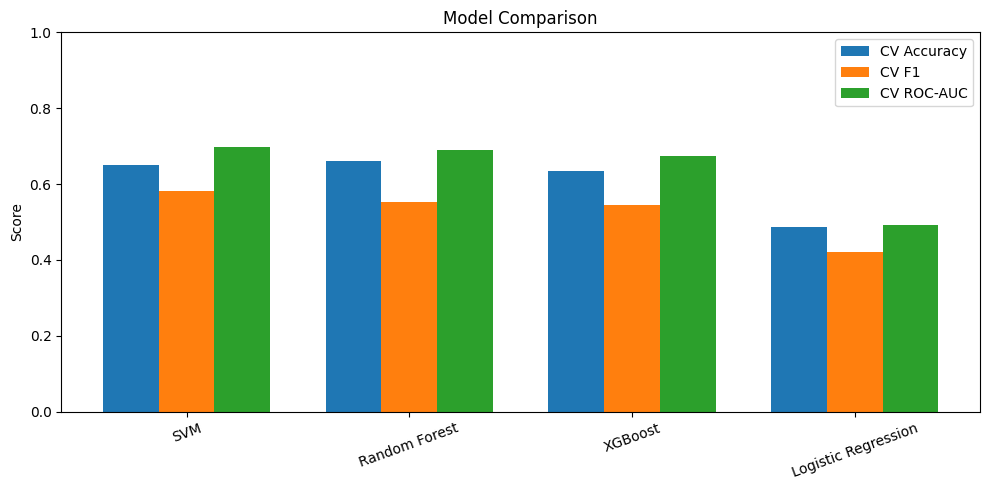

In [9]:
metrics=["CV Accuracy","CV F1","CV ROC-AUC"]; x=np.arange(len(comparison)); w=.25
plt.figure(figsize=(10,5))
for i,m in enumerate(metrics): plt.bar(x+(i-1)*w,comparison[m],w,label=m)
plt.xticks(x,comparison["Model"],rotation=20); plt.ylim(0,1); plt.legend(); plt.ylabel("Score"); plt.title("Model Comparison"); plt.tight_layout(); plt.show()

## 7. Validation threshold optimization

In [10]:
best_model_name=comparison.iloc[0]["Model"]
final_model=fitted[best_model_name]
val_prob=final_model.predict_proba(X_val)[:,1]
thresholds=np.arange(.20,.81,.01)
f1s=[f1_score(y_val,(val_prob>=t).astype(int)) for t in thresholds]
best_threshold=float(thresholds[int(np.argmax(f1s))])
print("Selected model:",best_model_name)
print("Selected threshold:",round(best_threshold,2))
print("Validation F1:",round(max(f1s),4))

Selected model: SVM
Selected threshold: 0.39
Validation F1: 0.5778


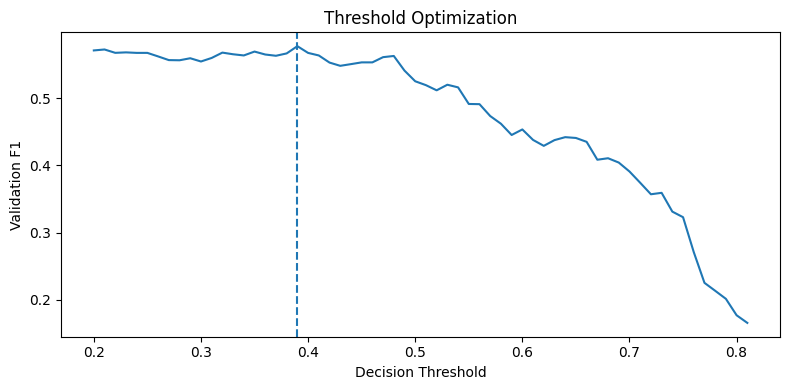

In [11]:
plt.figure(figsize=(8,4)); plt.plot(thresholds,f1s); plt.axvline(best_threshold,linestyle="--")
plt.xlabel("Decision Threshold"); plt.ylabel("Validation F1"); plt.title("Threshold Optimization"); plt.tight_layout(); plt.show()

## 8. Final test evaluation

In [12]:
test_prob=final_model.predict_proba(X_test)[:,1]
test_pred=(test_prob>=best_threshold).astype(int)
metrics_final={
"Accuracy":accuracy_score(y_test,test_pred),
"Precision":precision_score(y_test,test_pred,zero_division=0),
"Recall":recall_score(y_test,test_pred,zero_division=0),
"F1 Score":f1_score(y_test,test_pred,zero_division=0),
"ROC-AUC":roc_auc_score(y_test,test_prob)}
display(pd.DataFrame([metrics_final]).round(4))
print(classification_report(y_test,test_pred,target_names=["Non-potable","Potable"],zero_division=0))

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,0.5503,0.4488,0.668,0.5369,0.6411


              precision    recall  f1-score   support

 Non-potable       0.69      0.47      0.56       400
     Potable       0.45      0.67      0.54       256

    accuracy                           0.55       656
   macro avg       0.57      0.57      0.55       656
weighted avg       0.60      0.55      0.55       656



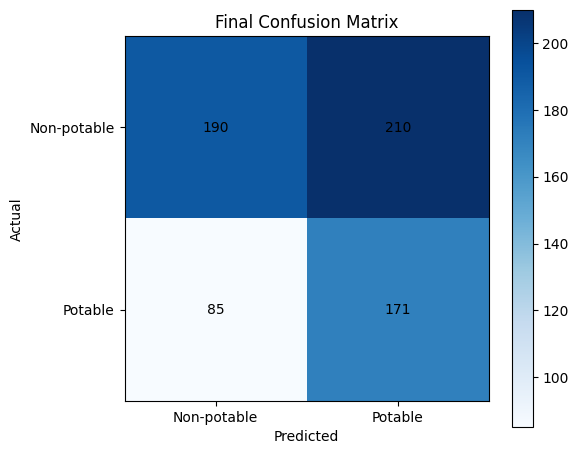

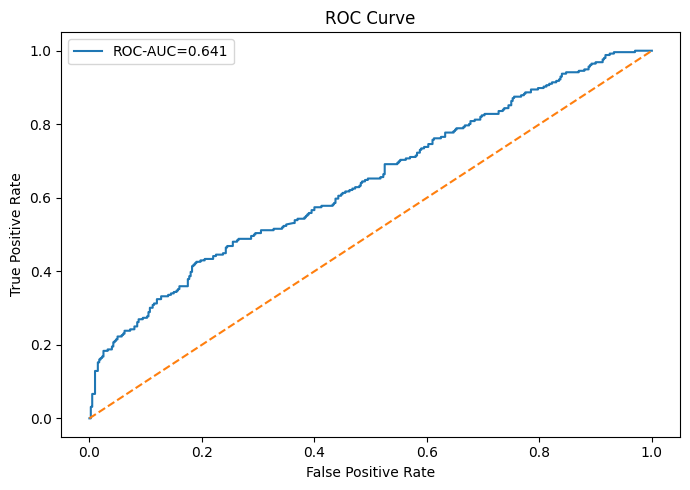

In [13]:
cm=confusion_matrix(y_test,test_pred)
plt.figure(figsize=(6,5)); plt.imshow(cm,cmap="Blues"); plt.colorbar()
plt.xticks([0,1],["Non-potable","Potable"]); plt.yticks([0,1],["Non-potable","Potable"])
for i in range(2):
    for j in range(2): plt.text(j,i,cm[i,j],ha="center",va="center")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Final Confusion Matrix"); plt.tight_layout(); plt.show()
fpr,tpr,_=roc_curve(y_test,test_prob)
plt.figure(figsize=(7,5)); plt.plot(fpr,tpr,label=f"ROC-AUC={metrics_final['ROC-AUC']:.3f}"); plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("ROC Curve"); plt.legend(); plt.tight_layout(); plt.show()

## 9. Explainability

,Feature,Importance
0,ph,0.0
1,Hardness,0.0
2,Solids,0.0
3,Chloramines,0.0
4,Sulfate,0.0
5,Conductivity,0.0
6,Organic_carbon,0.0
7,Trihalomethanes,0.0
8,Turbidity,0.0


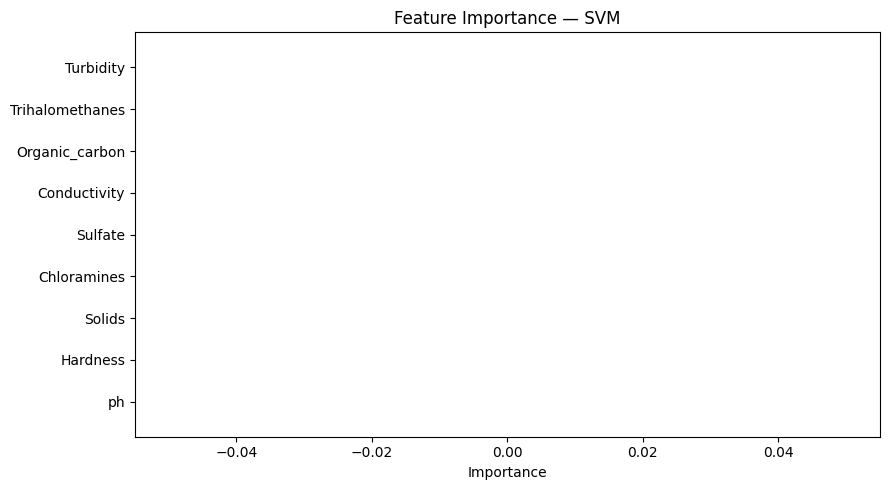

In [14]:
model_step=final_model.named_steps["model"]
if hasattr(model_step,"feature_importances_"): values=model_step.feature_importances_
elif hasattr(model_step,"coef_"): values=np.abs(model_step.coef_[0])
else: values=np.zeros(len(feature_names))
importance_df=pd.DataFrame({"Feature":feature_names,"Importance":values}).sort_values("Importance",ascending=False)
display(importance_df.round(4))
ordered=importance_df.sort_values("Importance")
plt.figure(figsize=(9,5)); plt.barh(ordered["Feature"],ordered["Importance"]); plt.xlabel("Importance")
plt.title(f"Feature Importance — {best_model_name}"); plt.tight_layout(); plt.show()

## 10. Reusable prediction function

In [15]:
def predict_water_quality(ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity):
    sample=pd.DataFrame([{
        "ph":ph,"Hardness":Hardness,"Solids":Solids,"Chloramines":Chloramines,
        "Sulfate":Sulfate,"Conductivity":Conductivity,"Organic_carbon":Organic_carbon,
        "Trihalomethanes":Trihalomethanes,"Turbidity":Turbidity
    }])
    probability=float(final_model.predict_proba(sample)[0,1])
    prediction=int(probability>=best_threshold)
    risk="Lower ML risk" if probability>=.70 else ("Moderate ML risk" if probability>=.40 else "Higher ML risk")
    return {"Prediction":"Potable" if prediction else "Non-potable","Potability Probability":round(probability,4),"AquaGuard Risk Indicator":risk}

In [16]:
sample=X_test.iloc[0]
print(predict_water_quality(*[sample[c] for c in feature_names]))

{'Prediction': 'Potable', 'Potability Probability': 0.671, 'AquaGuard Risk Indicator': 'Moderate ML risk'}


# Conclusion
AquaGuard provides a leakage-aware end-to-end water-potability workflow with model comparison, threshold optimization, evaluation and explainability.

### Future extensions
- Add geographic/seasonal measurements.
- Add laboratory rule-based safety limits as a separate layer.
- Build a Streamlit interface.
- Add SHAP explanations.
- Save the trained pipeline with joblib.
- Connect to real-time sensors.

**Academic disclaimer:** ML predictions should not replace certified water-quality testing.